
# Spam Detection Project

This project is a simple Machine Learning example where we classify messages as:
- **Spam** (Unwanted message)
- **Ham** (Normal message)


In [3]:

# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")


Libraries imported successfully!


In [6]:
# Loading the dataset
data = pd.read_csv("spam.csv")

print("Dataset loaded successfully!")

# Check structure
print("\nColumns:", data.columns)
print("\nTotal rows:", len(data))

data.head()


Dataset loaded successfully!

Columns: Index(['label', 'message'], dtype='object')

Total rows: 50


,label,message
0,spam,Win a free iPhone now! Click here to claim you...
1,ham,Hey are you coming to the meeting tomorrow
2,spam,Congratulations you have been selected for a c...
3,ham,Can you send me the notes from class today
4,spam,URGENT Your account has been compromised click...


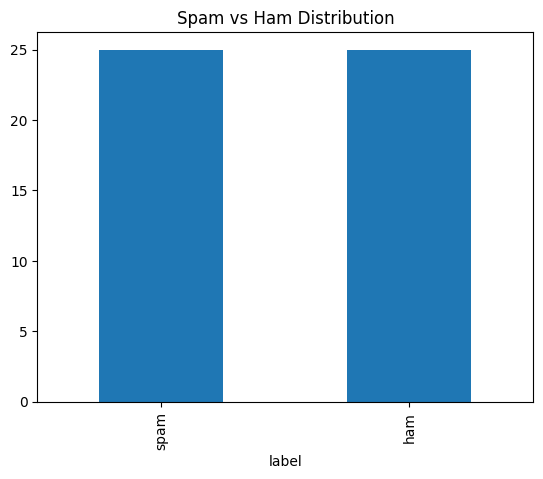

In [7]:

# Checking how many spam and ham messages we have
data["label"].value_counts().plot(kind="bar")
plt.title("Spam vs Ham Distribution")
plt.show()


In [8]:

# Converting labels into numbers
# ham = 0, spam = 1
data["target"] = data["label"].map({"ham": 0, "spam": 1})

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    data["message"], data["target"], 
    test_size=0.2, 
    random_state=42
)

print("Data split into training and testing sets!")


Data split into training and testing sets!


In [9]:

# Converting text into numbers using TF-IDF
vectorizer = TfidfVectorizer(stop_words="english")

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Text converted into numerical format!")
print("Training data shape:", X_train_tfidf.shape)


Text converted into numerical format!
Training data shape: (40, 146)


In [10]:

# Training the Naive Bayes model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")


Model trained successfully!


In [11]:

# Making predictions
predictions = model.predict(X_test_tfidf)

# Checking accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, predictions))


Accuracy: 0.7

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.57      1.00      0.73         4

    accuracy                           0.70        10
   macro avg       0.79      0.75      0.70        10
weighted avg       0.83      0.70      0.69        10



In [12]:

# Function to check new messages
def check_message(text):
    text_vector = vectorizer.transform([text])
    result = model.predict(text_vector)
    
    if result[0] == 1:
        return "SPAM"
    else:
        return "HAM"

# Testing with example messages
msg1 = "Congratulations! You have won a free lottery ticket."
msg2 = "Hey, are we meeting tomorrow?"

print(msg1, "->", check_message(msg1))
print(msg2, "->", check_message(msg2))


Congratulations! You have won a free lottery ticket. -> SPAM
Hey, are we meeting tomorrow? -> HAM
